In [4]:
%matplotlib inline
import pandas as pd
import sys
sys.path.append("..")
from scripts.radar_chart import plot_radar

df = pd.read_csv("../data/clean/ranked_central_midfields.csv")



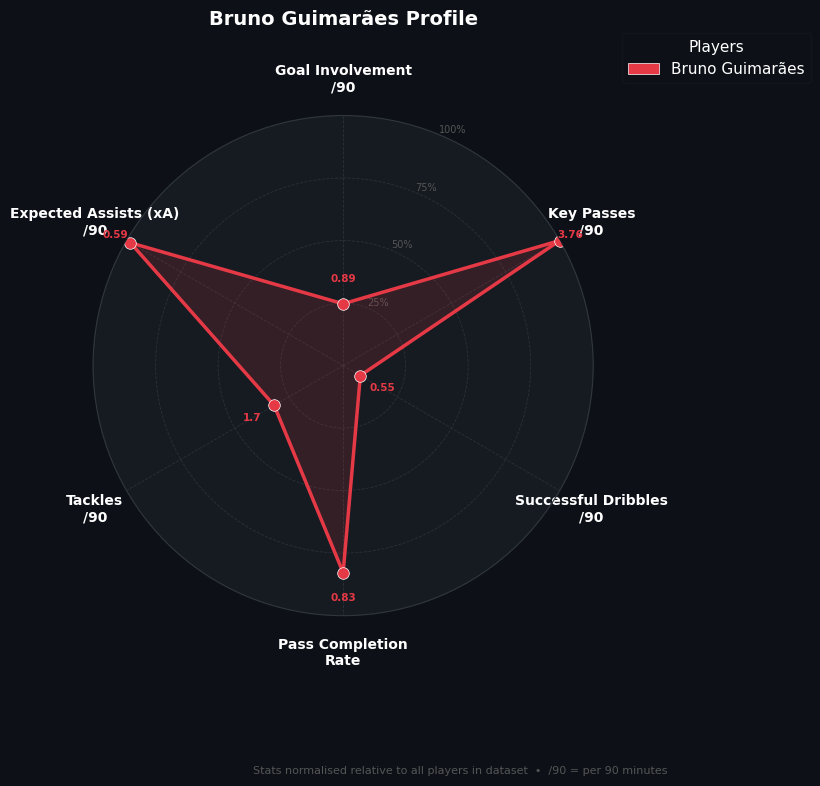

(<Figure size 900x900 with 1 Axes>,
 <PolarAxes: title={'center': 'Bruno Guimarães Profile'}>)

In [5]:
plot_radar(
    df,
    players=["Bruno Guimarães"],
    role="Mezzala",
    title="Bruno Guimarães Profile",
)

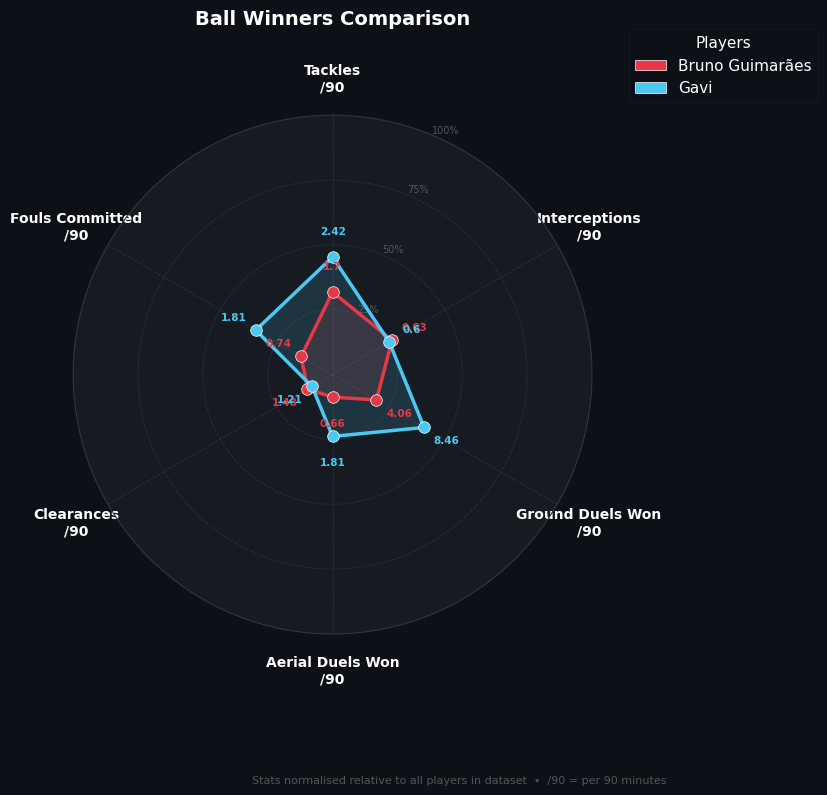

(<Figure size 900x900 with 1 Axes>,
 <PolarAxes: title={'center': 'Ball Winners Comparison'}>)

In [6]:
plot_radar(
    df,
    players=["Bruno Guimarães", "Gavi"],
    role="Ball Winning Midfielder",
    title="Ball Winners Comparison",
)

In [28]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   

In [29]:

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n   = 200

roles = np.random.choice(['Forward','Midfielder','Defender'], n,
                          p=[0.30, 0.40, 0.30])

df = pd.DataFrame({
    'player':              [f'Player_{i}' for i in range(n)],
    'position':            roles,
    'market_value_eur':    rng.uniform(1e6, 120e6, n),
    'goals':               rng.integers(0, 30, n),
    'assists':             rng.integers(0, 20, n),
    'shots_on_target':     rng.integers(0, 80, n),
    'key_passes':          rng.integers(0, 100, n),
    'dribbles_completed':  rng.integers(0, 60, n),
    'xg':                  rng.uniform(0, 20, n),
    'tackles':             rng.integers(0, 80, n),
    'interceptions':       rng.integers(0, 60, n),
    'clearances':          rng.integers(0, 100, n),
    'aerial_duels_won':    rng.integers(0, 70, n),
    'blocks':              rng.integers(0, 50, n),
    'pass_accuracy':       rng.uniform(50, 95, n),
    'progressive_passes':  rng.integers(0, 90, n),
    'through_balls':       rng.integers(0, 30, n),
})

# add a standout player for demo purposes
df.loc[0] = {
    'player': 'Demo Star', 'position': 'Forward',
    'market_value_eur': 8e6,      
    'goals': 28, 'assists': 12, 'shots_on_target': 75,
    'key_passes': 90, 'dribbles_completed': 55, 'xg': 18.5,
    'tackles': 10, 'interceptions': 8, 'clearances': 5,
    'aerial_duels_won': 20, 'blocks': 4, 'pass_accuracy': 82,
    'progressive_passes': 60, 'through_balls': 18,
}
print(df.head()) 

      player    position  market_value_eur  goals  assists  shots_on_target  \
0  Demo Star     Forward      8.000000e+06     28       12               75   
1   Player_1  Midfielder      5.322653e+07     23       15               24   
2   Player_2     Forward      1.031732e+08      9       14               41   
3   Player_3  Midfielder      8.398680e+07     29        2               73   
4   Player_4  Midfielder      1.220710e+07     14       16               59   

   key_passes  dribbles_completed         xg  tackles  interceptions  \
0          90                  55  18.500000       10              8   
1          73                  28   6.449847       37              3   
2          55                  59   3.108831       36             23   
3          88                  45  17.486287       20             27   
4          12                  39   5.664939       10             47   

   clearances  aerial_duels_won  blocks  pass_accuracy  progressive_passes  \
0           5 

 Performance vs Market Value

In [24]:
import importlib
import scripts.performance_vs_value

importlib.reload(scripts.performance_vs_value)

<module 'scripts.performance_vs_value' from 'e:\\Git Projects\\football-analytics\\scripts\\performance_vs_value.py'>

e:\Git Projects\football-analytics\scripts\performance_vs_value.py:212: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 1])
c:\Users\lenovo\miniconda3\envs\football\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


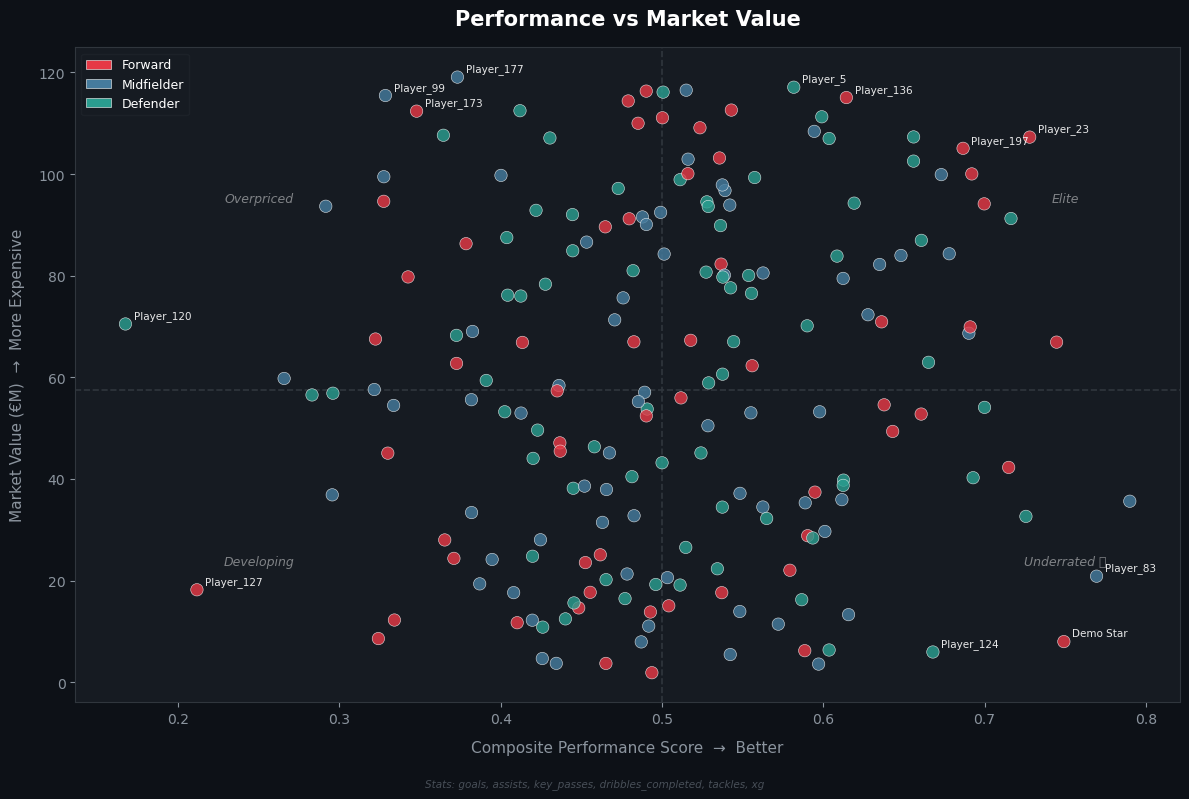

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Performance vs Market Value'}, xlabel='Composite Performance Score  →  Better', ylabel='Market Value (€M)  →  More Expensive'>)

In [30]:
from scripts.performance_vs_value import plot_performance_vs_value

plot_performance_vs_value(
    df,
    perf_cols=["goals", "assists", "key_passes",
               "dribbles_completed", "tackles", "xg"],
    value_col="market_value_eur",
    name_col="player",
    role_col="position",
    role_filter=None,       
    top_n_labels=12,
    save_path=None,        
)

Role Comparison

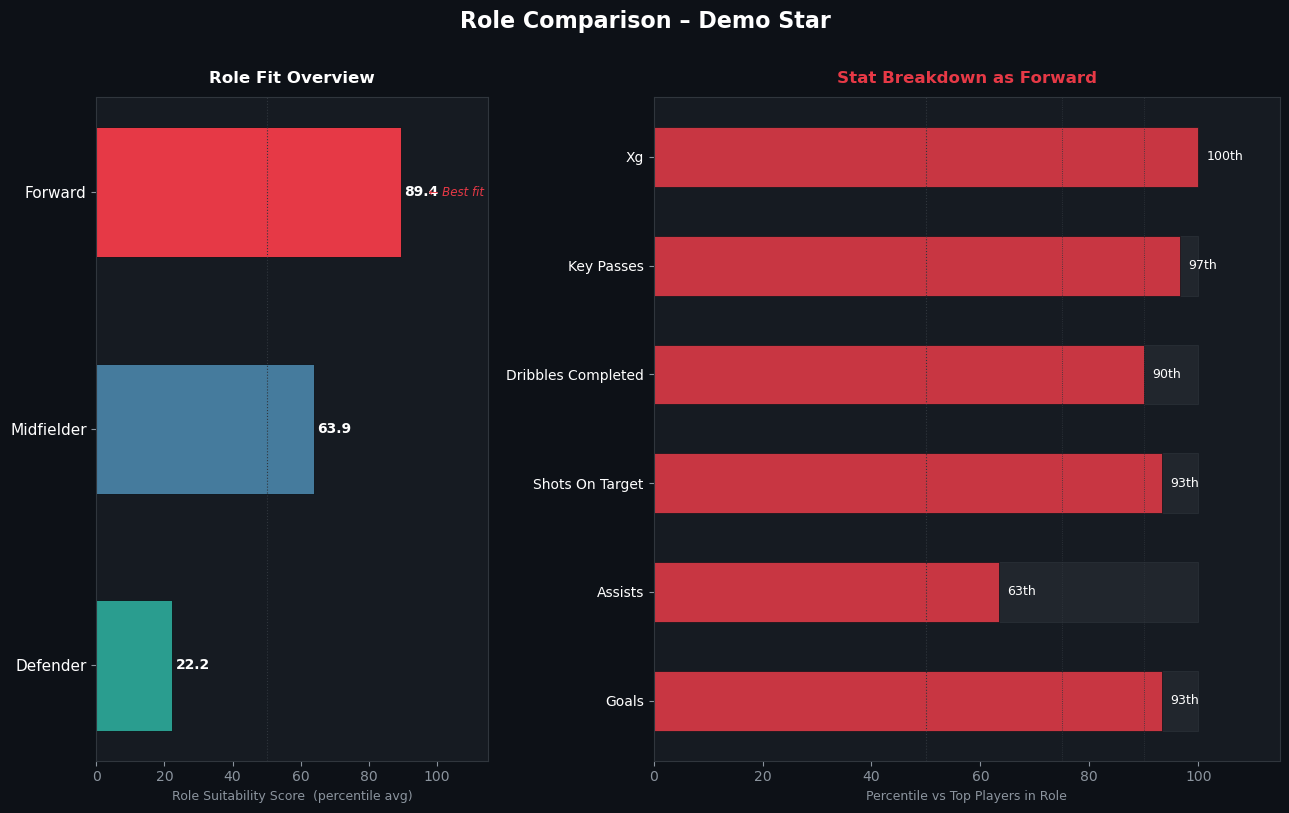

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: title={'center': 'Role Fit Overview'}, xlabel='Role Suitability Score  (percentile avg)'>,
  <Axes: title={'center': 'Stat Breakdown as Forward'}, xlabel='Percentile vs Top Players in Role'>))

In [16]:
from scripts.role_comparison import plot_role_comparison

plot_role_comparison(
    df,
    player_name="Demo Star",
    name_col="player",
    role_col="position",
    roles=["Forward", "Midfielder", "Defender"],
    role_stats={
        "Forward":    ["goals", "assists", "shots_on_target",
                       "dribbles_completed", "key_passes", "xg"],
        "Midfielder": ["key_passes", "assists", "pass_accuracy",
                       "dribbles_completed", "tackles", "progressive_passes"],
        "Defender":   ["tackles", "interceptions", "clearances",
                       "aerial_duels_won", "blocks", "pass_accuracy"],
    },
    top_n=30,
    save_path=None,
)